# Zero-Shot vs SFT-Only Ablation — Combined Results

Compares zero-shot (base) and SFT-only fine-tuned models from the **`eval-all`** W&B project.
For each model family, shows the delta from zero-shot → SFT.

**Benchmarks**: GoldCoin-HIPAA (applicability + compliance), PrivacyLens (QA probing + leakage), VLM-GeoPrivacy (Q7)

**Models with both conditions**: Qwen3.5-9B, Phi-4, Gemma-3-12B-IT

In [1]:
import wandb
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Latex

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Configuration ──────────────────────────────────────────────────────────
WANDB_ENTITY = "uair"
WANDB_PROJECT = "eval-all"

# Models that have BOTH zero-shot and SFT results
# checkpoint_name → paper display label
MODEL_DISPLAY = {
    "Qwen3.5-2B": "Qwen3.5-2B",
    "Qwen3.5-4B": "Qwen3.5-4B",
    "Qwen3.5-9B": "Qwen3.5-9B",
    "Gemma-3-12B-IT": "Gemma-3-12B",
    "Llama-3.2-11B-Vision": "Llama-3.2-11B",
    "Phi-4": "Phi-4",
    "Phi-4-multimodal-instruct": "Phi-4-MM",
    "GPT-OSS-20B": "GPT-OSS-20B",
    "OpenThinker3-7B": "OpenThinker3-7B",
}

# SFT checkpoint_name → base model name (for pairing)
SFT_TO_BASE = {
    "Qwen3.5-2B+sft_only": "Qwen3.5-2B",
    "Qwen3.5-4B+sft_only": "Qwen3.5-4B",
    "Qwen3.5-9B+sft_only": "Qwen3.5-9B",
    "Llama-3.2-11B-Vision+sft_only": "Llama-3.2-11B-Vision",
    "Phi-4+sft_only": "Phi-4",
    "Phi-4-multimodal-instruct+sft_only": "Phi-4-multimodal-instruct",
    "Gemma-3-12B-IT+sft_only": "Gemma-3-12B-IT",
    "Qwen3.5-9B+checkpoint_vlm_patched": "Qwen3.5-9B",  # VLM SFT variant
    "GPT-OSS-20B-SFT-merged": "GPT-OSS-20B",
    "OpenThinker3-7B+sft_only": "OpenThinker3-7B",
}

MODEL_ORDER = list(MODEL_DISPLAY.values())

api = wandb.Api()
print(f"Connected to W&B entity={WANDB_ENTITY}, project={WANDB_PROJECT}")

Connected to W&B entity=uair, project=eval-all


## 1. Fetch runs from W&B

We pull both `base`-tagged (zero-shot) and `finetuned`-tagged (SFT-only) runs.

In [2]:
# Fetch base and finetuned runs
base_runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$in": ["base"]}},
)
sft_runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$in": ["finetuned"]}},
)
print(f"Found {len(base_runs)} base-tagged runs, {len(sft_runs)} finetuned-tagged runs")

Found 159 base-tagged runs, 253 finetuned-tagged runs


## 2. Extract metrics into a unified DataFrame

Same metric extraction as the zero-shot notebook, but now we also tag each row
with a `condition` column (`zero-shot` or `sft`).

In [3]:
def extract_run_metrics(run, condition: str) -> dict | None:
    """Extract structured metrics from a single W&B run.
    
    For SFT runs, maps checkpoint_name back to base model name for pairing.
    """
    config = run.config
    summary = run.summary
    tags = set(run.tags)
    
    checkpoint = config.get("model", {}).get("checkpoint_name", "")
    if not checkpoint:
        return None
    
    # Map SFT checkpoint names back to base model name
    if condition == "sft":
        base_name = SFT_TO_BASE.get(checkpoint)
        if base_name is None:
            return None  # unknown SFT checkpoint
        model_name = base_name
    else:
        model_name = checkpoint
    
    # Only keep models we're comparing
    if model_name not in MODEL_DISPLAY:
        return None
    
    dagspace = None
    for t in tags:
        if t.startswith("bench:"):
            dagspace = t.split(":", 1)[1]
            break
    if not dagspace:
        return None
    
    row = {
        "model": model_name,
        "condition": condition,
        "dagspace": dagspace,
        "run_id": run.id,
        "checkpoint_raw": checkpoint,
    }
    has_metrics = False
    
    if dagspace == "goldcoin_hipaa":
        app_f1 = summary.get("compute_metrics/eval/applicable/f1")
        notapp_f1 = summary.get("compute_metrics/eval/not_applicable/f1")
        permit_f1 = summary.get("compute_metrics/eval/permit/f1")
        forbid_f1 = summary.get("compute_metrics/eval/forbid/f1")
        if app_f1 is not None and notapp_f1 is not None:
            row["gc_applicability_f1"] = (app_f1 + notapp_f1) / 2
            has_metrics = True
        if permit_f1 is not None and forbid_f1 is not None:
            row["gc_compliance_f1"] = (permit_f1 + forbid_f1) / 2
            has_metrics = True
    elif dagspace == "privacylens":
        qa_acc = summary.get("compute_metrics/eval/qa_accuracy")
        leak = summary.get("compute_metrics/eval/leakage_rate")
        adj_leak = summary.get("compute_metrics/eval/adjusted_leakage_rate")
        helpful = summary.get("compute_metrics/eval/helpful_rate")
        if qa_acc is not None or leak is not None:
            row["pl_qa_accuracy"] = qa_acc
            row["pl_leakage_rate"] = leak
            row["pl_adjusted_leakage_rate"] = adj_leak
            row["pl_helpful_rate"] = helpful
            has_metrics = True
    elif dagspace == "vlm_geoprivacy_bench":
        q7_acc = summary.get("compute_metrics/eval/Q7/accuracy")
        if q7_acc is not None:
            row["vlm_q7_accuracy"] = q7_acc
            has_metrics = True
    
    return row if has_metrics else None


rows = []
for r in base_runs:
    m = extract_run_metrics(r, "zero-shot")
    if m is not None:
        rows.append(m)
for r in sft_runs:
    m = extract_run_metrics(r, "sft")
    if m is not None:
        rows.append(m)

df_raw = pd.DataFrame(rows)
print(f"Extracted {len(df_raw)} metric rows")
print(f"Models: {sorted(df_raw['model'].unique())}")
print(f"Conditions: {sorted(df_raw['condition'].unique())}")
print(f"Benchmarks: {sorted(df_raw['dagspace'].unique())}")
display(df_raw)

Extracted 77 metric rows
Models: ['GPT-OSS-20B', 'Gemma-3-12B-IT', 'OpenThinker3-7B', 'Phi-4', 'Phi-4-multimodal-instruct', 'Qwen3.5-2B', 'Qwen3.5-4B', 'Qwen3.5-9B']
Conditions: ['sft', 'zero-shot']
Benchmarks: ['goldcoin_hipaa', 'privacylens', 'vlm_geoprivacy_bench']


,model,condition,dagspace,run_id,checkpoint_raw,gc_applicability_f1,gc_compliance_f1,pl_qa_accuracy,pl_leakage_rate,pl_adjusted_leakage_rate,pl_helpful_rate,vlm_q7_accuracy
0,Qwen3.5-2B,zero-shot,goldcoin_hipaa,hr4qetln,Qwen3.5-2B,0.576,0.586,NaN,NaN,NaN,NaN,NaN
1,Qwen3.5-4B,zero-shot,goldcoin_hipaa,jj77ycjq,Qwen3.5-4B,0.901,0.731,NaN,NaN,NaN,NaN,NaN
2,Qwen3.5-9B,zero-shot,goldcoin_hipaa,8xb69mrp,Qwen3.5-9B,0.953,0.704,NaN,NaN,NaN,NaN,NaN
3,Qwen3.5-2B,zero-shot,privacylens,16c1seea,Qwen3.5-2B,NaN,NaN,0.983,0.116,NaN,NaN,NaN
4,Qwen3.5-4B,zero-shot,privacylens,6h6zp8v4,Qwen3.5-4B,NaN,NaN,0.903,0.617,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
72,Qwen3.5-2B,sft,privacylens,8aydioyy,Qwen3.5-2B+sft_only,NaN,NaN,0.995,0.199,0.178,0.558,NaN
73,OpenThinker3-7B,sft,privacylens,6fcoqlpn,OpenThinker3-7B+sft_only,NaN,NaN,0.959,0.195,0.201,0.686,NaN
74,Phi-4,sft,privacylens,bz96dugw,Phi-4+sft_only,NaN,NaN,0.972,0.189,0.185,0.964,NaN
75,Qwen3.5-9B,sft,privacylens,a15taw02,Qwen3.5-9B+sft_only,NaN,NaN,0.976,0.172,0.170,0.945,NaN


In [4]:
df_raw['checkpoint_raw'].value_counts()

checkpoint_raw
Qwen3.5-2B                           12
Qwen3.5-4B                           10
Qwen3.5-9B                           10
Qwen3.5-4B+sft_only                   8
Qwen3.5-2B+sft_only                   7
Qwen3.5-9B+sft_only                   6
OpenThinker3-7B+sft_only              4
OpenThinker3-7B                       4
Gemma-3-12B-IT                        3
Qwen3.5-9B+checkpoint_vlm_patched     2
GPT-OSS-20B                           2
Phi-4                                 2
GPT-OSS-20B-SFT-merged                2
Gemma-3-12B-IT+sft_only               2
Phi-4+sft_only                        2
Phi-4-multimodal-instruct             1
Name: count, dtype: int64

## 3. Pivot into comparison table

One row per (model, condition). Merge GoldCoin, PrivacyLens, and VLM metrics.

In [5]:
# De-duplicate: keep last run per (model, condition, dagspace)
df_dedup = df_raw.drop_duplicates(subset=["model", "condition", "dagspace"], keep="last")

METRIC_COLS = {
    "gc_applicability_f1": "App F1",
    "gc_compliance_f1": "Comp F1",
    "pl_qa_accuracy": "QA Acc",
    "pl_adjusted_leakage_rate": "Adj Leak",
    "pl_helpful_rate": "Helpful",
    "vlm_q7_accuracy": "Q7 Acc",
}

def pivot_for_condition(df, dagspace, cols):
    """Extract metrics for a given dagspace."""
    sub = df[df["dagspace"] == dagspace][["model", "condition"] + list(cols.keys())]
    return sub.rename(columns=cols)

# ── GoldCoin ──
gc = pivot_for_condition(df_dedup, "goldcoin_hipaa",
    {"gc_applicability_f1": "App F1", "gc_compliance_f1": "Comp F1"})

# ── PrivacyLens ──
pl = pivot_for_condition(df_dedup, "privacylens",
    {"pl_qa_accuracy": "QA Acc", "pl_adjusted_leakage_rate": "Adj Leak",
     "pl_helpful_rate": "Helpful"})

# ── VLM ──
vlm = pivot_for_condition(df_dedup, "vlm_geoprivacy_bench",
    {"vlm_q7_accuracy": "Q7 Acc"})

# ── Merge ──
df_table = gc.merge(pl, on=["model", "condition"], how="outer") \
             .merge(vlm, on=["model", "condition"], how="outer")

df_table["Model"] = df_table["model"].map(MODEL_DISPLAY).fillna(df_table["model"])

# Convert to percentage
for c in ["App F1", "Comp F1", "QA Acc", "Adj Leak", "Helpful", "Q7 Acc"]:
    if c in df_table.columns:
        df_table[c] = df_table[c] * 100

# Sort: group by model order, zero-shot before sft within each
condition_order = {"zero-shot": 0, "sft": 1}
model_order_map = {m: i for i, m in enumerate(MODEL_ORDER)}
df_table["_model_rank"] = df_table["Model"].map(model_order_map).fillna(99)
df_table["_cond_rank"] = df_table["condition"].map(condition_order)
df_table = df_table.sort_values(["_model_rank", "_cond_rank"]).drop(columns=["_model_rank", "_cond_rank", "model"])

display(df_table.round(2))

,condition,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc,Model
10,zero-shot,56.890,58.600,98.310,26.900,69.370,21.200,Qwen3.5-2B
9,sft,80.320,44.840,99.530,17.820,55.780,21.200,Qwen3.5-2B
12,zero-shot,90.110,72.210,90.470,27.730,89.250,51.210,Qwen3.5-4B
11,sft,69.570,72.330,95.060,19.230,94.930,51.470,Qwen3.5-4B
14,zero-shot,95.320,72.350,95.330,22.420,90.470,63.470,Qwen3.5-9B
13,sft,93.430,75.080,97.570,16.950,94.520,60.540,Qwen3.5-9B
3,zero-shot,94.380,74.350,98.380,27.270,89.250,40.740,Gemma-3-12B
2,sft,79.580,74.350,98.650,23.110,91.280,NaN,Gemma-3-12B
7,zero-shot,96.260,66.980,97.030,20.520,93.910,NaN,Phi-4
6,sft,89.130,61.980,97.160,18.530,96.350,NaN,Phi-4


## 4. Compute deltas (SFT - Zero-Shot)

For each model + metric, compute the absolute change from zero-shot → SFT.

In [6]:
metric_cols = [c for c in ["App F1", "Comp F1", "QA Acc", "Adj Leak", "Helpful", "Q7 Acc"]
               if c in df_table.columns]

# Pivot wide: one row per model, columns = (metric, condition)
df_wide = df_table.pivot_table(index="Model", columns="condition", values=metric_cols)

# Build delta table
delta_rows = []
for model in MODEL_ORDER:
    if model not in df_wide.index:
        continue
    row = {"Model": model}
    for col in metric_cols:
        zs = df_wide.loc[model].get((col, "zero-shot"), np.nan)
        sft = df_wide.loc[model].get((col, "sft"), np.nan)
        row[f"{col} (ZS)"] = zs
        row[f"{col} (SFT)"] = sft
        if pd.notna(zs) and pd.notna(sft):
            row[f"{col} (Δ)"] = sft - zs
        else:
            row[f"{col} (Δ)"] = np.nan
    delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows).set_index("Model")
display(df_delta.round(2))

,App F1 (ZS),App F1 (SFT),App F1 (Δ),Comp F1 (ZS),Comp F1 (SFT),Comp F1 (Δ),QA Acc (ZS),QA Acc (SFT),QA Acc (Δ),Adj Leak (ZS),Adj Leak (SFT),Adj Leak (Δ),Helpful (ZS),Helpful (SFT),Helpful (Δ),Q7 Acc (ZS),Q7 Acc (SFT),Q7 Acc (Δ)
Model,,,,,,,,,,,,,,,,,,
Qwen3.5-2B,56.890,80.320,23.430,58.600,44.840,-13.750,98.310,99.530,1.220,26.900,17.820,-9.080,69.370,55.780,-13.590,21.200,21.200,0.000
Qwen3.5-4B,90.110,69.570,-20.540,72.210,72.330,0.120,90.470,95.060,4.590,27.730,19.230,-8.500,89.250,94.930,5.680,51.210,51.470,0.260
Qwen3.5-9B,95.320,93.430,-1.890,72.350,75.080,2.730,95.330,97.570,2.240,22.420,16.950,-5.470,90.470,94.520,4.050,63.470,60.540,-2.930
Gemma-3-12B,94.380,79.580,-14.800,74.350,74.350,0.000,98.380,98.650,0.270,27.270,23.110,-4.160,89.250,91.280,2.030,40.740,NaN,NaN
Phi-4,96.260,89.130,-7.120,66.980,61.980,-5.000,97.030,97.160,0.130,20.520,18.530,-1.990,93.910,96.350,2.440,NaN,NaN,NaN
Phi-4-MM,73.310,NaN,NaN,58.080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GPT-OSS-20B,77.330,62.870,-14.460,65.320,57.080,-8.240,89.590,85.400,-4.190,12.110,16.190,4.080,92.090,85.190,-6.900,NaN,NaN,NaN
OpenThinker3-7B,77.020,83.000,5.980,15.750,15.750,0.000,86.000,95.880,9.880,27.080,20.120,-6.960,38.950,68.560,29.610,NaN,NaN,NaN


## 5. Generate LaTeX table

Grouped rows per model: zero-shot row, SFT row, delta row. Benchmark columns grouped with `\cmidrule`.

In [7]:
def build_comparison_latex(df_delta: pd.DataFrame) -> str:
    """Generate a booktabs LaTeX table comparing zero-shot vs SFT."""
    gc_cols = ["App F1", "Comp F1"]
    pl_cols = ["QA Acc", "Adj Leak", "Helpful"]
    vlm_cols = ["Q7 Acc"]
    all_metric_names = [c for c in gc_cols + pl_cols + vlm_cols
                        if f"{c} (ZS)" in df_delta.columns]
    
    lower_better = {"Adj Leak"}
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Zero-shot vs.\ SFT-only performance across CI benchmarks (\%). "
                 r"Adj Leak = leakage among helpful responses only. "
                 r"$\Delta$ = SFT $-$ zero-shot. $\downarrow$ = lower is better.}")
    lines.append(r"\label{tab:zero-shot-vs-sft}")
    n_data_cols = len(all_metric_names)
    lines.append(r"\begin{tabular}{ll" + "c" * n_data_cols + "}")
    lines.append(r"\toprule")
    
    # Header row 1: benchmark groups
    gc_present = [c for c in gc_cols if c in all_metric_names]
    pl_present = [c for c in pl_cols if c in all_metric_names]
    vlm_present = [c for c in vlm_cols if c in all_metric_names]
    
    group_header = " & "
    col_idx = 3  # starts after Model + Condition columns
    cmidrules = []
    if gc_present:
        group_header += rf" & \multicolumn{{{len(gc_present)}}}{{c}}{{\textbf{{GoldCoin-HIPAA}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(gc_present) - 1}}}")
        col_idx += len(gc_present)
    if pl_present:
        group_header += rf" & \multicolumn{{{len(pl_present)}}}{{c}}{{\textbf{{PrivacyLens}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(pl_present) - 1}}}")
        col_idx += len(pl_present)
    if vlm_present:
        group_header += rf" & \multicolumn{{{len(vlm_present)}}}{{c}}{{\textbf{{VLM-GeoPri.}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(vlm_present) - 1}}}")
    
    lines.append(group_header + r" \\")
    lines.append(" ".join(cmidrules))
    
    # Header row 2: metric names
    col_labels = {
        "App F1": r"App F1",
        "Comp F1": r"Comp F1",
        "QA Acc": r"QA Acc",
        "Adj Leak": r"Adj Leak $\downarrow$",
        "Helpful": r"Helpful",
        "Q7 Acc": r"Q7 Acc",
    }
    col_headers = [r"\textbf{Model}", r"\textbf{Cond.}"] + [col_labels.get(c, c) for c in all_metric_names]
    lines.append(" & ".join(col_headers) + r" \\")
    lines.append(r"\midrule")
    
    # Body: one group per model (zero-shot, SFT, delta)
    for i, (model_name, row) in enumerate(df_delta.iterrows()):
        # Zero-shot row
        zs_cells = [model_name, "Zero-shot"]
        for col in all_metric_names:
            val = row.get(f"{col} (ZS)", np.nan)
            zs_cells.append("---" if pd.isna(val) else f"{val:.1f}")
        lines.append(" & ".join(zs_cells) + r" \\")
        
        # SFT row
        sft_cells = ["", "SFT"]
        for col in all_metric_names:
            val = row.get(f"{col} (SFT)", np.nan)
            sft_cells.append("---" if pd.isna(val) else f"{val:.1f}")
        lines.append(" & ".join(sft_cells) + r" \\")
        
        # Delta row
        delta_cells = ["", r"$\Delta$"]
        for col in all_metric_names:
            val = row.get(f"{col} (Δ)", np.nan)
            if pd.isna(val):
                delta_cells.append("---")
            else:
                sign = "+" if val > 0 else ""
                txt = f"{sign}{val:.1f}"
                improved = (val < 0) if col in lower_better else (val > 0)
                if improved:
                    txt = rf"\textcolor{{teal}}{{{txt}}}"
                elif val != 0:
                    txt = rf"\textcolor{{red}}{{{txt}}}"
                delta_cells.append(txt)
        lines.append(" & ".join(delta_cells) + r" \\")
        
        # Separator between model groups
        if i < len(df_delta) - 1:
            lines.append(r"\addlinespace")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


latex = build_comparison_latex(df_delta)
print(latex)

\begin{table}[t]
\centering
\caption{Zero-shot vs.\ SFT-only performance across CI benchmarks (\%). Adj Leak = leakage among helpful responses only. $\Delta$ = SFT $-$ zero-shot. $\downarrow$ = lower is better.}
\label{tab:zero-shot-vs-sft}
\begin{tabular}{llcccccc}
\toprule
 &  & \multicolumn{2}{c}{\textbf{GoldCoin-HIPAA}} & \multicolumn{3}{c}{\textbf{PrivacyLens}} & \multicolumn{1}{c}{\textbf{VLM-GeoPri.}} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-7} \cmidrule(lr){8-8}
\textbf{Model} & \textbf{Cond.} & App F1 & Comp F1 & QA Acc & Adj Leak $\downarrow$ & Helpful & Q7 Acc \\
\midrule
Qwen3.5-2B & Zero-shot & 56.9 & 58.6 & 98.3 & 26.9 & 69.4 & 21.2 \\
 & SFT & 80.3 & 44.8 & 99.5 & 17.8 & 55.8 & 21.2 \\
 & $\Delta$ & \textcolor{teal}{+23.4} & \textcolor{red}{-13.8} & \textcolor{teal}{+1.2} & \textcolor{teal}{-9.1} & \textcolor{red}{-13.6} & 0.0 \\
\addlinespace
Qwen3.5-4B & Zero-shot & 90.1 & 72.2 & 90.5 & 27.7 & 89.2 & 51.2 \\
 & SFT & 69.6 & 72.3 & 95.1 & 19.2 & 94.9 & 51.5 \\
 & $\Delta$ 

## 6. Save LaTeX table

In [8]:
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "zero_shot_vs_sft.tex"
out_path.write_text(latex)
print(f"Saved to {out_path.resolve()}")

Saved to /share/pierson/matt/UAIR/notebooks/COLM26/tables/zero_shot_vs_sft.tex


## 7. Comparative bar plots

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

# Colors for conditions
COND_COLORS = {"zero-shot": "#4C72B0", "sft": "#DD8452"}

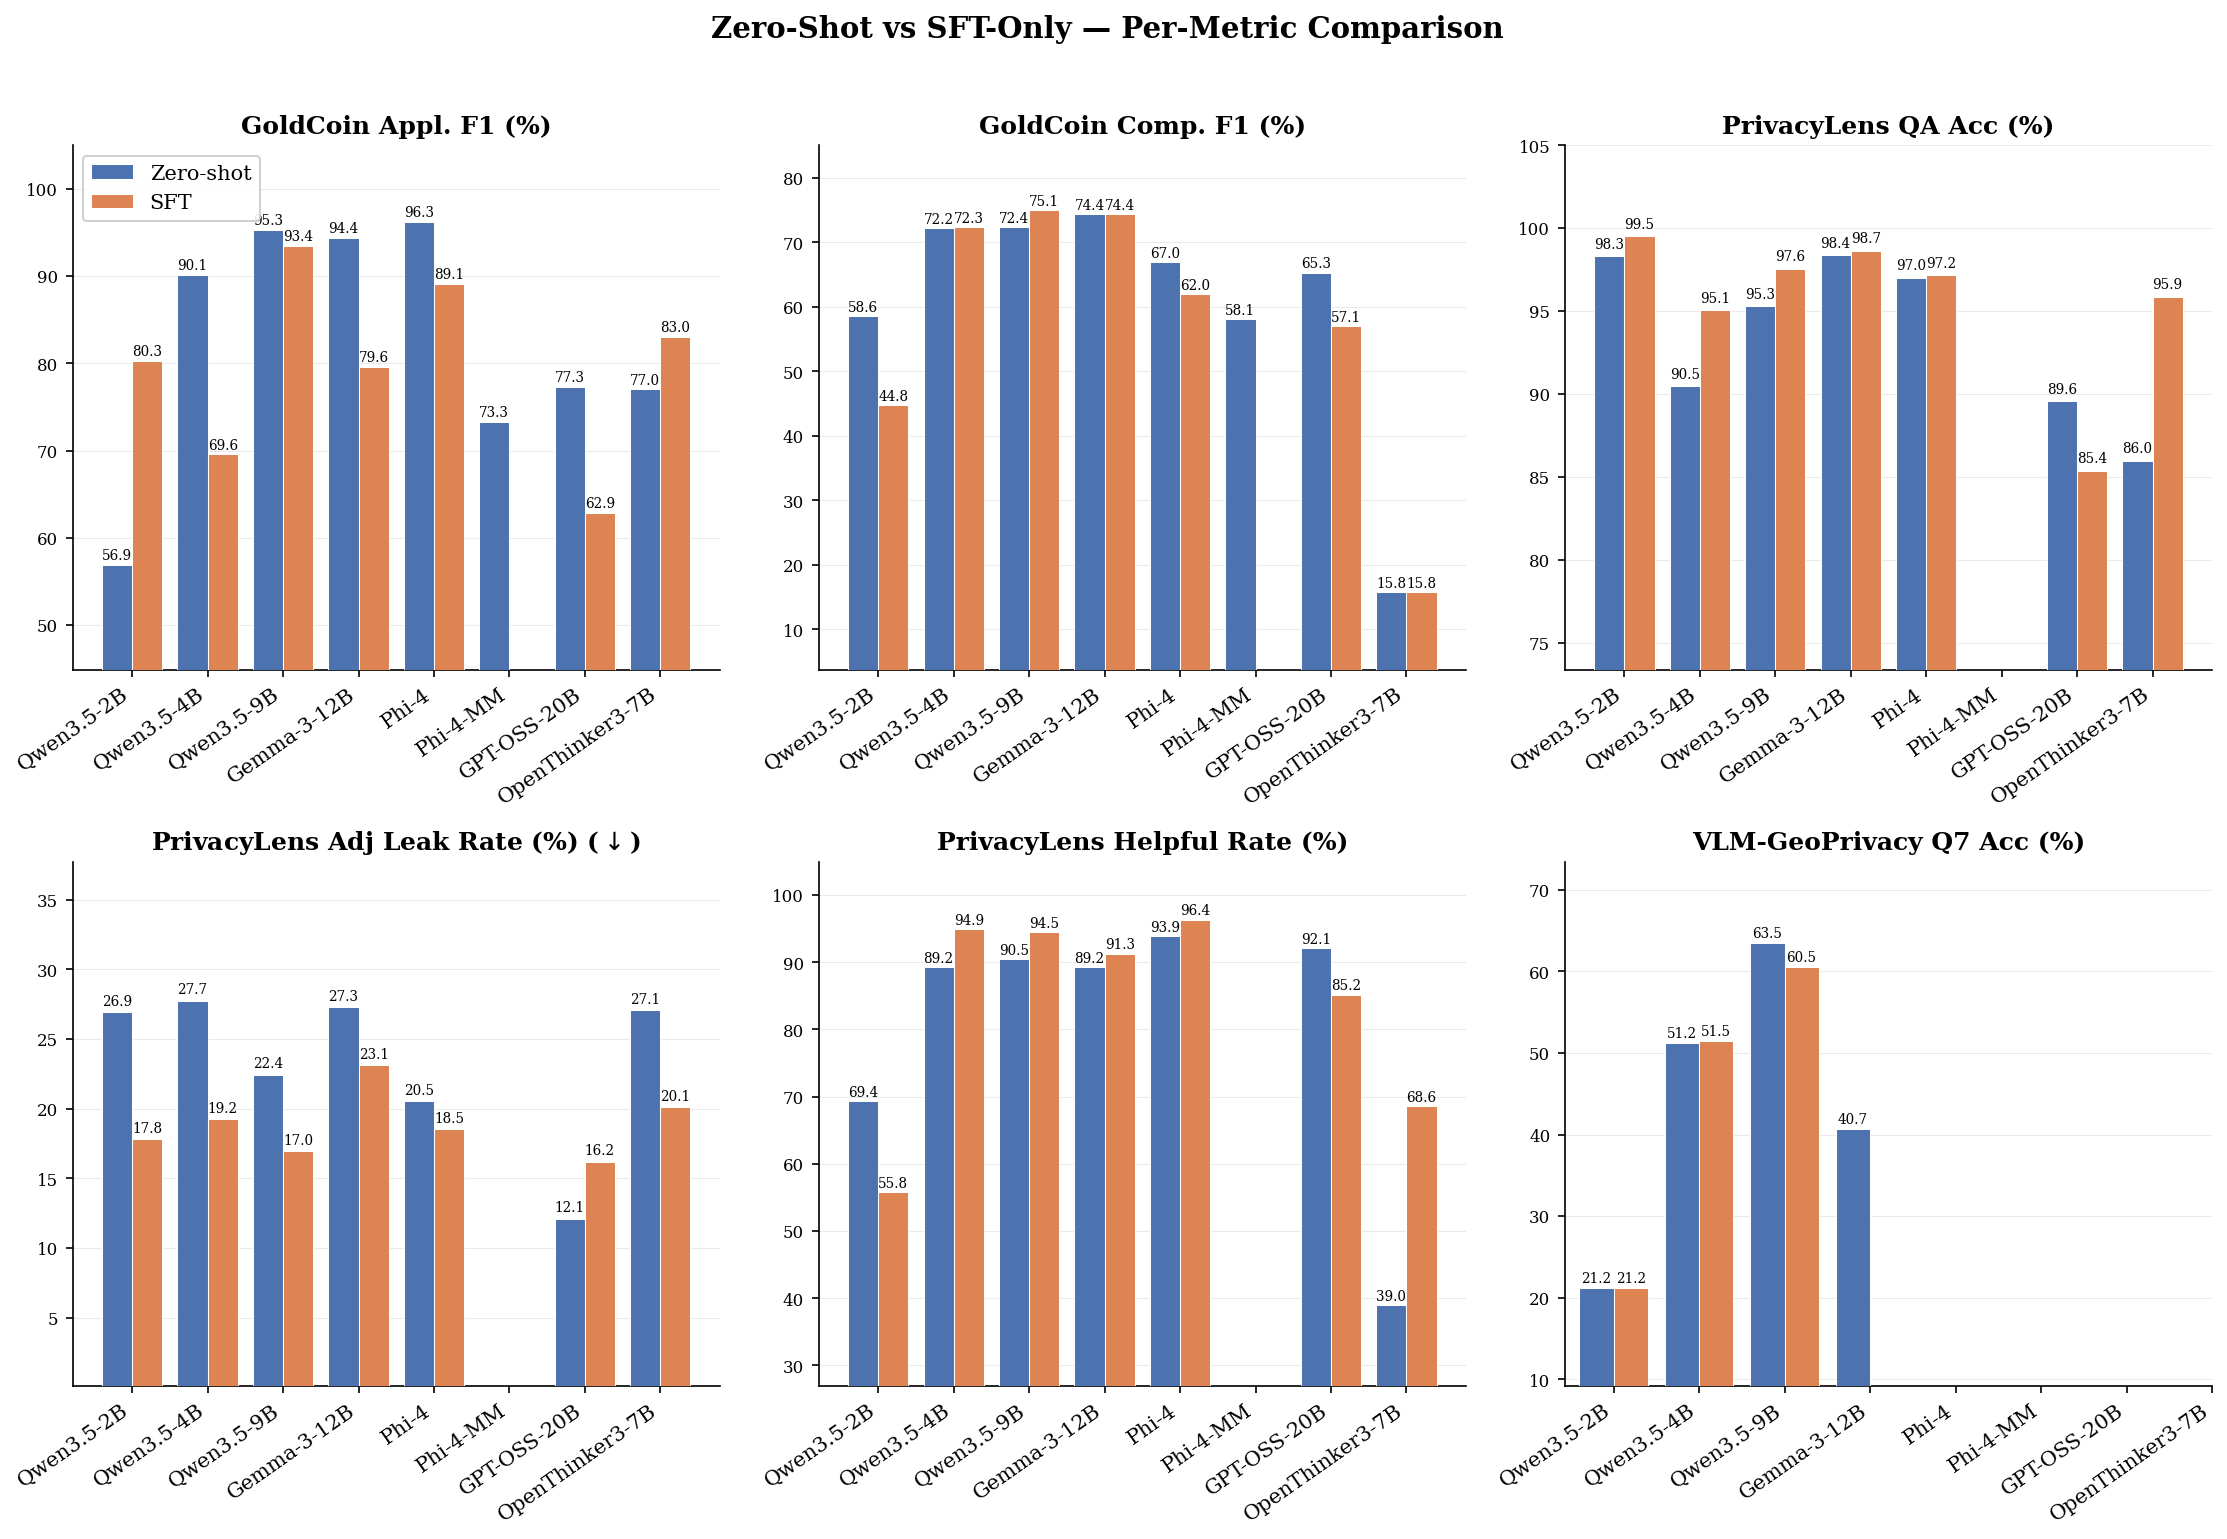

In [10]:
# ── Figure 1: Grouped bar chart per metric (zero-shot vs SFT side by side) ──
from math import ceil 
metric_spec = [
    ("App F1",    "GoldCoin Appl. F1 (%)",          True),
    ("Comp F1",   "GoldCoin Comp. F1 (%)",          True),
    ("QA Acc",    "PrivacyLens QA Acc (%)",          True),
    ("Adj Leak",  "PrivacyLens Adj Leak Rate (%)",   False),  # lower is better
    ("Helpful",   "PrivacyLens Helpful Rate (%)",    True),
    ("Q7 Acc",    "VLM-GeoPrivacy Q7 Acc (%)",       True),
]
metric_spec = [(col, label, hb) for col, label, hb in metric_spec
               if f"{col} (ZS)" in df_delta.columns]

models = list(df_delta.index)
n_models = len(models)
n_metrics = len(metric_spec)
bar_w = 0.4
x = np.arange(n_models)

ncols = ceil(n_metrics / 2)
fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 10), squeeze=False)
axes = axes.flatten()

for ax, (col, label, higher_better) in zip(axes, metric_spec):
    zs_vals = df_delta[f"{col} (ZS)"].reindex(models).values
    sft_vals = df_delta[f"{col} (SFT)"].reindex(models).values
    
    bars_zs = ax.bar(x - bar_w/2, zs_vals, bar_w, color=COND_COLORS["zero-shot"],
                     label="Zero-shot", edgecolor="white", linewidth=0.5, zorder=3)
    bars_sft = ax.bar(x + bar_w/2, sft_vals, bar_w, color=COND_COLORS["sft"],
                      label="SFT", edgecolor="white", linewidth=0.5, zorder=3)
    
    # Annotate values
    for bars in [bars_zs, bars_sft]:
        for bar in bars:
            h = bar.get_height()
            if pd.notna(h) and h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + 0.3, f"{h:.1f}",
                        ha="center", va="bottom", fontsize=6.5, fontweight="medium")
    
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha="right", fontsize=10)
    suffix = "" if higher_better else r" ($\downarrow$)"
    ax.set_title(label + suffix, fontsize=12, fontweight="bold")
    
    # y-axis range
    all_vals = np.concatenate([zs_vals, sft_vals])
    valid = all_vals[~np.isnan(all_vals)]
    if len(valid):
        lo = max(0, valid.min() - 12)
        hi = min(valid.max() + 10, 105)
        ax.set_ylim(lo, hi)

# Common legend
axes[0].legend(loc="upper left", framealpha=0.9, fontsize=10)
# Remove empty subplots
for ax in axes[n_metrics:]:
    ax.axis("off")

fig.suptitle("Zero-Shot vs SFT-Only — Per-Metric Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("tables/zero_shot_vs_sft_per_metric.pdf")
plt.show()